In [1]:
from utils import *


In [ ]:
subject_data = load_pickle("../analyses/lsa_decision_spm/subject_data_tavares.pkl")
betas = subject_data[18001]['roi_betas']['HPC-L']

In [44]:
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
from typing import Literal, Optional, Dict, Any, Tuple

def neural_subject_similarity_matrix(
    subject_data: Dict,
    incl_subs: Sequence[int],
    *,
    roi: str,
    method: str = "rdm_spearman",   # {"rdm_spearman","pattern_pearson"}
    rdm_metric: str = "corr",       # {"corr"}  (easy to extend)
    zscore_voxels: bool = True,
    min_trials: int = 6,
    min_features: int = 10,
    return_long: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute an N x N subject-by-subject neural similarity matrix for a given ROI.

    Parameters
    ----------
    subject_data
        Dict like: subject_data[sub_id]['roi_betas'][roi] -> array (n_trials, n_voxels)
    incl_subs
        Subject IDs to include (order preserved, but subjects missing data are dropped).
    roi
        ROI key (e.g., "HPC-L")
    method
        - "rdm_spearman": For each subject, compute trial-by-trial RDM (1 - corr across trials),
          then compute subject-subject similarity as Spearman correlation between vectorized
          upper triangles of the RDMs (second-order RSA).
        - "pattern_pearson": Flatten the trial-by-voxel matrix per subject and correlate
          subjects directly (Pearson).
    rdm_metric
        Currently only "corr": distance = 1 - Pearson correlation across trial patterns.
    zscore_voxels
        If True, z-score each voxel/feature column within-subject before any correlations.
    min_trials, min_features
        Minimum requirements for inclusion.
    return_long
        If True, also return a dyad-level DataFrame (i<j) with similarity values.

    Returns
    -------
    sim_mat : pd.DataFrame
        N x N similarity matrix indexed/columned by sub_id.
    info : pd.DataFrame
        Per-subject info: n_trials, n_features, dropped_reason (if dropped).
        If return_long=True, the second returned value is the long dyad DataFrame instead,
        and per-subject info is attached as an attribute: long_df.attrs["subject_info"].
    """
    # ----------------------------
    # Helpers (kept inside main fn)
    # ----------------------------
    def _as_2d_float(a):
        a = np.asarray(a)
        if a.ndim == 1:
            a = a[:, None]
        return a.astype(float, copy=False)

    def _zscore_cols(X, eps=1e-12):
        mu = np.nanmean(X, axis=0, keepdims=True)
        sd = np.nanstd(X, axis=0, ddof=1, keepdims=True)
        return (X - mu) / (sd + eps)

    def _drop_bad_rows(X):
        X = np.asarray(X, float)
        good = np.isfinite(X).all(axis=1)
        return X[good], int(good.sum())

    def _trial_corr_rdm(X):
        """
        X: (n_trials, n_features)
        Returns: RDM (n_trials, n_trials) with entries 1 - corr(trial_i, trial_j)
        """
        # Pearson correlation across trials: corrcoef on rows if we transpose
        # corrcoef wants variables in rows by default if rowvar=True; we want trials as variables.
        # So use rowvar=True on X (trials are rows): corrcoef(X) gives trial-trial corr.
        C = np.corrcoef(X)  # (n_trials, n_trials)
        # Guard numeric issues:
        C = np.clip(C, -1.0, 1.0)
        D = 1.0 - C
        np.fill_diagonal(D, 0.0)
        return D

    def _spearman(x, y):
        # scipy not required; do rank correlation with pandas (stable, handles ties)
        x = pd.Series(x).rank(method="average").to_numpy(float)
        y = pd.Series(y).rank(method="average").to_numpy(float)
        # Pearson on ranks
        x = x - x.mean()
        y = y - y.mean()
        denom = (np.sqrt((x * x).sum()) * np.sqrt((y * y).sum()))
        if denom <= 0:
            return np.nan
        return float((x * y).sum() / denom)

    # ----------------------------
    # Build per-subject representations
    # ----------------------------
    subj_rows = []
    reps = {}  # sub_id -> representation vector
    for sub_id in incl_subs:
        reason = ""
        X = None

        try:
            X = subject_data[sub_id]["roi_betas"][roi]
        except Exception:
            reason = "missing_roi_betas"
            subj_rows.append(dict(sub_id=sub_id, n_trials=np.nan, n_features=np.nan, dropped_reason=reason))
            continue

        X = _as_2d_float(X)
        X, n_kept = _drop_bad_rows(X)
        n_trials, n_feat = X.shape if X is not None else (0, 0)

        if n_trials < min_trials:
            reason = f"too_few_trials(<{min_trials})"
        elif n_feat < min_features:
            reason = f"too_few_features(<{min_features})"

        if reason:
            subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=reason))
            continue

        if zscore_voxels:
            X = _zscore_cols(X)

        if method == "rdm_spearman":
            if rdm_metric != "corr":
                reason = f"unsupported_rdm_metric({rdm_metric})"
                subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=reason))
                continue

            RDM = _trial_corr_rdm(X)
            # You said you already have flatten_upper_tri; use it.
            # Expectation: flatten_upper_tri(RDM) -> 1D vector of upper triangle (k=1).
            v = flatten_upper_tri(RDM)
            reps[sub_id] = np.asarray(v, float)

        elif method == "pattern_pearson":
            reps[sub_id] = X.reshape(-1).astype(float, copy=False)

        else:
            reason = f"unsupported_method({method})"
            subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=reason))
            continue

        subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=""))

    info_df = pd.DataFrame(subj_rows)
    kept_subs = [s for s in incl_subs if s in reps]

    # ----------------------------
    # Compute subject-by-subject similarity matrix
    # ----------------------------
    N = len(kept_subs)
    sim = np.full((N, N), np.nan, float)

    for i, si in enumerate(kept_subs):
        sim[i, i] = 1.0
        vi = reps[si]
        for j in range(i + 1, N):
            sj = kept_subs[j]
            vj = reps[sj]

            if method == "rdm_spearman":
                sij = _spearman(vi, vj)
            else:  # pattern_pearson
                # Pearson correlation between flattened patterns
                xi = vi
                xj = vj
                good = np.isfinite(xi) & np.isfinite(xj)
                if good.sum() < 3:
                    sij = np.nan
                else:
                    a = xi[good] - np.nanmean(xi[good])
                    b = xj[good] - np.nanmean(xj[good])
                    denom = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum())
                    sij = np.nan if denom <= 0 else float((a * b).sum() / denom)

            sim[i, j] = sij
            sim[j, i] = sij

    sim_df = pd.DataFrame(sim, index=kept_subs, columns=kept_subs)

    if not return_long:
        return sim_df, info_df

    # Dyad-level (i<j)
    rows = []
    for i, si in enumerate(kept_subs):
        for j in range(i + 1, N):
            sj = kept_subs[j]
            rows.append(dict(sub_i=si, sub_j=sj, sim=float(sim_df.loc[si, sj])))
    long_df = pd.DataFrame(rows)
    long_df.attrs["subject_info"] = info_df
    return sim_df, long_df

def neural_subject_similarity_matrix(
    subject_data: Dict,
    incl_subs: Sequence[int],
    *,
    roi: str,
    method: str = "rdm_spearman",   # {"rdm_spearman","pattern_pearson"}
    rdm_metric: str = "corr",       # {"corr"}
    zscore_voxels: bool = True,
    min_trials: int = 6,
    min_features: int = 10,
    return_long: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame, list]:
    """
    Returns:
      sim_df   : (N x N) similarity matrix (kept subjects only)
      info_df  : per-subject inclusion info (all attempted subjects)
      kept_subs: list of subjects actually included (order preserved)
    """
    def _as_2d_float(a):
        a = np.asarray(a)
        if a.ndim == 1:
            a = a[:, None]
        return a.astype(float, copy=False)

    def _zscore_cols(X, eps=1e-12):
        mu = np.nanmean(X, axis=0, keepdims=True)
        sd = np.nanstd(X, axis=0, ddof=1, keepdims=True)
        return (X - mu) / (sd + eps)

    def _drop_bad_rows(X):
        X = np.asarray(X, float)
        good = np.isfinite(X).all(axis=1)
        return X[good]

    def _trial_corr_rdm(X):
        C = np.corrcoef(X)  # trials x trials correlation (trials are rows)
        C = np.clip(C, -1.0, 1.0)
        D = 1.0 - C
        np.fill_diagonal(D, 0.0)
        return D

    def _spearman(x, y):
        # rank then Pearson
        rx = pd.Series(x).rank(method="average").to_numpy(float)
        ry = pd.Series(y).rank(method="average").to_numpy(float)
        rx = rx - rx.mean()
        ry = ry - ry.mean()
        denom = np.sqrt((rx * rx).sum()) * np.sqrt((ry * ry).sum())
        if denom <= 0:
            return np.nan
        return float((rx * ry).sum() / denom)

    def _pearson(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() < 3:
            return np.nan
        a = x[good] - x[good].mean()
        b = y[good] - y[good].mean()
        denom = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum())
        if denom <= 0:
            return np.nan
        return float((a * b).sum() / denom)

    subj_rows = []
    reps = {}

    for sub_id in incl_subs:
        reason = ""
        try:
            X = subject_data[sub_id]["roi_betas"][roi]
        except Exception:
            subj_rows.append(dict(sub_id=sub_id, n_trials=np.nan, n_features=np.nan, dropped_reason="missing_roi_betas"))
            continue

        X = _as_2d_float(X)
        X = _drop_bad_rows(X)
        n_trials, n_feat = X.shape

        if n_trials < min_trials:
            reason = f"too_few_trials(<{min_trials})"
        elif n_feat < min_features:
            reason = f"too_few_features(<{min_features})"
        if reason:
            subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=reason))
            continue

        if zscore_voxels:
            X = _zscore_cols(X)

        if method == "rdm_spearman":
            if rdm_metric != "corr":
                subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=f"unsupported_rdm_metric({rdm_metric})"))
                continue
            RDM = _trial_corr_rdm(X)
            v = np.asarray(flatten_upper_tri(RDM), float)  # uses your helper
            reps[sub_id] = v
        elif method == "pattern_pearson":
            reps[sub_id] = X.reshape(-1).astype(float, copy=False)
        else:
            subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=f"unsupported_method({method})"))
            continue

        subj_rows.append(dict(sub_id=sub_id, n_trials=n_trials, n_features=n_feat, dropped_reason=""))

    info_df = pd.DataFrame(subj_rows)
    kept_subs = [s for s in incl_subs if s in reps]

    N = len(kept_subs)
    sim = np.full((N, N), np.nan, float)
    for i, si in enumerate(kept_subs):
        sim[i, i] = 1.0
        vi = reps[si]
        for j in range(i + 1, N):
            sj = kept_subs[j]
            vj = reps[sj]
            sij = _spearman(vi, vj) if method == "rdm_spearman" else _pearson(vi, vj)
            sim[i, j] = sij
            sim[j, i] = sij

    sim_df = pd.DataFrame(sim, index=kept_subs, columns=kept_subs)

    if not return_long:
        return sim_df, info_df, kept_subs

    rows = []
    for i, si in enumerate(kept_subs):
        for j in range(i + 1, N):
            sj = kept_subs[j]
            rows.append(dict(sub_i=si, sub_j=sj, sim=float(sim_df.loc[si, sj])))
    long_df = pd.DataFrame(rows)
    long_df.attrs["subject_info"] = info_df
    return sim_df, long_df, kept_subs

def values_by_subject_order(
    df: pd.DataFrame,
    sub_ids: Sequence[int],
    *,
    value_col: str,
    sub_col: str = "sub_id",
    agg: str = "first",          # {"first","mean","median"}
    require_all: bool = True,
) -> np.ndarray:
    """
    Extract values from df[value_col] in the exact order of sub_ids.

    Handles duplicate sub_id rows via `agg`.
    If require_all=True, raises if any sub_id is missing or yields NaN.
    """
    if agg == "first":
        s = df.drop_duplicates(subset=[sub_col]).set_index(sub_col)[value_col]
    elif agg == "mean":
        s = df.groupby(sub_col, sort=False)[value_col].mean()
    elif agg == "median":
        s = df.groupby(sub_col, sort=False)[value_col].median()
    else:
        raise ValueError(f"Unknown agg={agg}")

    vals = np.array([s.get(int(i), np.nan) for i in sub_ids], dtype=float)

    if require_all:
        missing = [sub_ids[k] for k in range(len(sub_ids)) if not np.isfinite(vals[k])]
        if missing:
            raise ValueError(f"Missing/non-finite {value_col} for {len(missing)} subjects (e.g., {missing[:10]})")
    return vals

def rdm_from_scalars(
    x: np.ndarray,
    *,
    kind: str = "abs",          # {"abs","binary_threshold","binary_equal"}
    threshold: float = 0.0,
) -> np.ndarray:
    """
    Build an NxN RDM from a scalar per subject.

    - kind="abs":        RDM[i,j] = |x_i - x_j|
    - kind="binary_threshold": binarize x>threshold then RDM is 0 if same class else 1
    - kind="binary_equal":    RDM is 0 if x_i == x_j else 1 (useful if x already 0/1 or categories)
    """
    x = np.asarray(x, float)
    if x.ndim != 1:
        raise ValueError("x must be 1D (one scalar per subject).")
    if not np.isfinite(x).all():
        raise ValueError("x contains NaN/inf; filter or impute before building RDM.")

    if kind == "abs":
        return np.abs(x[:, None] - x[None, :])

    if kind == "binary_threshold":
        b = (x > float(threshold)).astype(int)
        return (b[:, None] != b[None, :]).astype(float)

    if kind == "binary_equal":
        return (x[:, None] != x[None, :]).astype(float)

    raise ValueError(f"Unknown kind={kind}")

def rdm_correlation_test_perm(
    A: np.ndarray | pd.DataFrame,
    B: np.ndarray | pd.DataFrame,
    *,
    a_is: Literal["rdm", "rsm"] = "rdm",   # rdm = dissimilarity; rsm = similarity
    b_is: Literal["rdm", "rsm"] = "rdm",
    metric: Literal["spearman", "pearson"] = "spearman",
    n_perm: int = 10_000,
    tail: Literal["two-sided", "greater", "less"] = "two-sided",
    permute: Literal["A", "B"] = "B",      # which matrix to relabel (rows+cols permuted together)
    seed: Optional[int] = 0,
    eps: float = 1e-12,
) -> Dict[str, Any]:
    """
    Correlate two subject-level (N x N) matrices with a permutation-derived null.

    Intended use: RSA / Mantel-style correlation between two RDMs (or RSMs).
    Permutation null is generated by simultaneously permuting rows+cols of one matrix,
    i.e. relabeling subject identities while preserving matrix structure.

    Returns dict with:
      r, p, z, n_pairs, null_mean, null_sd
      null (the null samples; length n_perm)
    """
    def _to_ndarray(x):
        if isinstance(x, pd.DataFrame):
            return x.to_numpy(float, copy=False)
        return np.asarray(x, float)

    def _as_dissim(M, kind: str):
        # If similarity, convert to dissimilarity with 1 - sim
        if kind == "rsm":
            return 1.0 - M
        return M

    def _upper_tri_vec(M):
        M = np.asarray(M, float)
        iu = np.triu_indices(M.shape[0], k=1)
        v = M[iu]
        return v

    def _pearson(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() < 3:
            return np.nan, int(good.sum())
        a = x[good] - np.mean(x[good])
        b = y[good] - np.mean(y[good])
        denom = np.sqrt(np.sum(a * a)) * np.sqrt(np.sum(b * b))
        if denom <= 0:
            return np.nan, int(good.sum())
        return float(np.sum(a * b) / denom), int(good.sum())

    def _spearman(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() < 3:
            return np.nan, int(good.sum())
        rx = pd.Series(x[good]).rank(method="average").to_numpy(float)
        ry = pd.Series(y[good]).rank(method="average").to_numpy(float)
        return _pearson(rx, ry)

    corr_fn = _spearman if metric == "spearman" else _pearson

    A = _to_ndarray(A)
    B = _to_ndarray(B)

    if A.ndim != 2 or B.ndim != 2 or A.shape[0] != A.shape[1] or B.shape[0] != B.shape[1]:
        raise ValueError("A and B must be square (N x N) matrices.")
    if A.shape != B.shape:
        raise ValueError(f"A and B must have the same shape. Got {A.shape} vs {B.shape}.")

    A = _as_dissim(A, a_is)
    B = _as_dissim(B, b_is)

    # Observed
    va = _upper_tri_vec(A)
    vb = _upper_tri_vec(B)
    r_obs, n_pairs = corr_fn(va, vb)

    # Permutation null via relabeling (row/col permutation together)
    rng = np.random.default_rng(seed)
    N = A.shape[0]
    null = np.full(int(n_perm), np.nan, float)

    for k in range(int(n_perm)):
        pidx = rng.permutation(N)
        if permute == "B":
            Bp = B[pidx][:, pidx]
            rb, _ = corr_fn(va, _upper_tri_vec(Bp))
        else:
            Ap = A[pidx][:, pidx]
            rb, _ = corr_fn(_upper_tri_vec(Ap), vb)
        null[k] = rb

    null = null[np.isfinite(null)]
    if null.size < max(10, int(0.1 * n_perm)):
        raise ValueError(
            f"Too few finite null samples ({null.size}/{n_perm}). "
            "Check for NaNs/infs or degenerate matrices."
        )

    null_mean = float(np.mean(null))
    null_sd = float(np.std(null, ddof=1)) if null.size >= 2 else np.nan
    z = float((r_obs - null_mean) / (null_sd + eps)) if np.isfinite(null_sd) else np.nan

    # Permutation p-value (with +1 correction)
    if not np.isfinite(r_obs):
        p = np.nan
    else:
        if tail == "two-sided":
            p = (1.0 + np.sum(np.abs(null) >= abs(r_obs))) / (null.size + 1.0)
        elif tail == "greater":
            p = (1.0 + np.sum(null >= r_obs)) / (null.size + 1.0)
        elif tail == "less":
            p = (1.0 + np.sum(null <= r_obs)) / (null.size + 1.0)
        else:
            raise ValueError(f"Unknown tail={tail}")

    return dict(
        r=float(r_obs),
        p=float(p),
        z=float(z),
        n_pairs=int(n_pairs),
        null_mean=float(null_mean),
        null_sd=float(null_sd),
        null=null,
        metric=metric,
        tail=tail,
        permute=permute,
        a_is=a_is,
        b_is=b_is,
        n_perm=int(n_perm),
        seed=seed,
    )

subject_data = load_pickle("../analyses/lsa_decision_spm/subject_data_tavares.pkl")

#---------------------------- compute matrices 

rows = []
rois = list(subject_data[18001]['roi_betas'].keys())
for roi in rois:
    rsm_roi, info_df, kept_subs = neural_subject_similarity_matrix(
        subject_data, incl_subs, roi=roi, method="rdm_spearman"
    )

    sa = values_by_subject_order(data, kept_subs, value_col="lsas_score", agg="first")
    rdm_sa = rdm_from_scalars(sa, kind="abs")

    dx = values_by_subject_order(data, kept_subs, value_col="dx", agg="first")
    rdm_dx = rdm_from_scalars(dx, kind="binary_equal")

    #---------------------------- run statistics

    # 1) Neural (RSM) vs SA (RDM) RSA:
    res_sa = rdm_correlation_test_perm(
        rsm_roi, rdm_sa,
        a_is="rsm", b_is="rdm",
        metric="spearman",
        n_perm=1000,
        tail="greater",
        permute="B",
        seed=0,
    )

    # 2) Neural (RSM) vs dx (RDM) RSA:
    res_dx = rdm_correlation_test_perm(
        rsm_roi, rdm_dx,
        a_is="rsm", b_is="rdm",
        metric="spearman",
        n_perm=1000,
        tail="greater",
        permute="B",
        seed=0,
    )

    for label, res in [("sa", res_sa), ("dx", res_dx)]:
        rows.append({
            "roi": roi,
            "contrast": label,
            "r": res["r"],
            "p": res["p"],
            "z": res["z"],
            "n_pairs": res["n_pairs"],
            "null_mean": res["null_mean"],
            "null_sd": res["null_sd"],
        })

results_df = pd.DataFrame(rows).set_index("contrast")
print(results_df)

              roi         r         p         z  n_pairs  null_mean   null_sd
contrast                                                                     
sa          HPC-L -0.017264  0.730270 -0.601351     2850  -0.000081  0.028574
dx          HPC-L -0.022287  0.901099 -1.220183     2850  -0.000924  0.017508
sa          HPC-R -0.001079  0.540460 -0.084053     2850   0.001202  0.027135
dx          HPC-R -0.011399  0.739261 -0.634744     2850  -0.000209  0.017631
sa          IPL-L  0.026905  0.201798  0.805045     2775   0.002366  0.030482
dx          IPL-L -0.009985  0.725275 -0.607000     2775   0.000125  0.016656
sa          IPL-R  0.017034  0.250749  0.671377     2628  -0.000624  0.026301
dx          IPL-R -0.014580  0.790210 -0.752186     2628  -0.000765  0.018367
sa        DLPFC-L -0.001345  0.516484 -0.038563     2850  -0.000125  0.031629
dx        DLPFC-L  0.018671  0.125874  1.185863     2850  -0.000756  0.016382
sa        DLPFC-R  0.005860  0.409590  0.234697     2850  -0.001

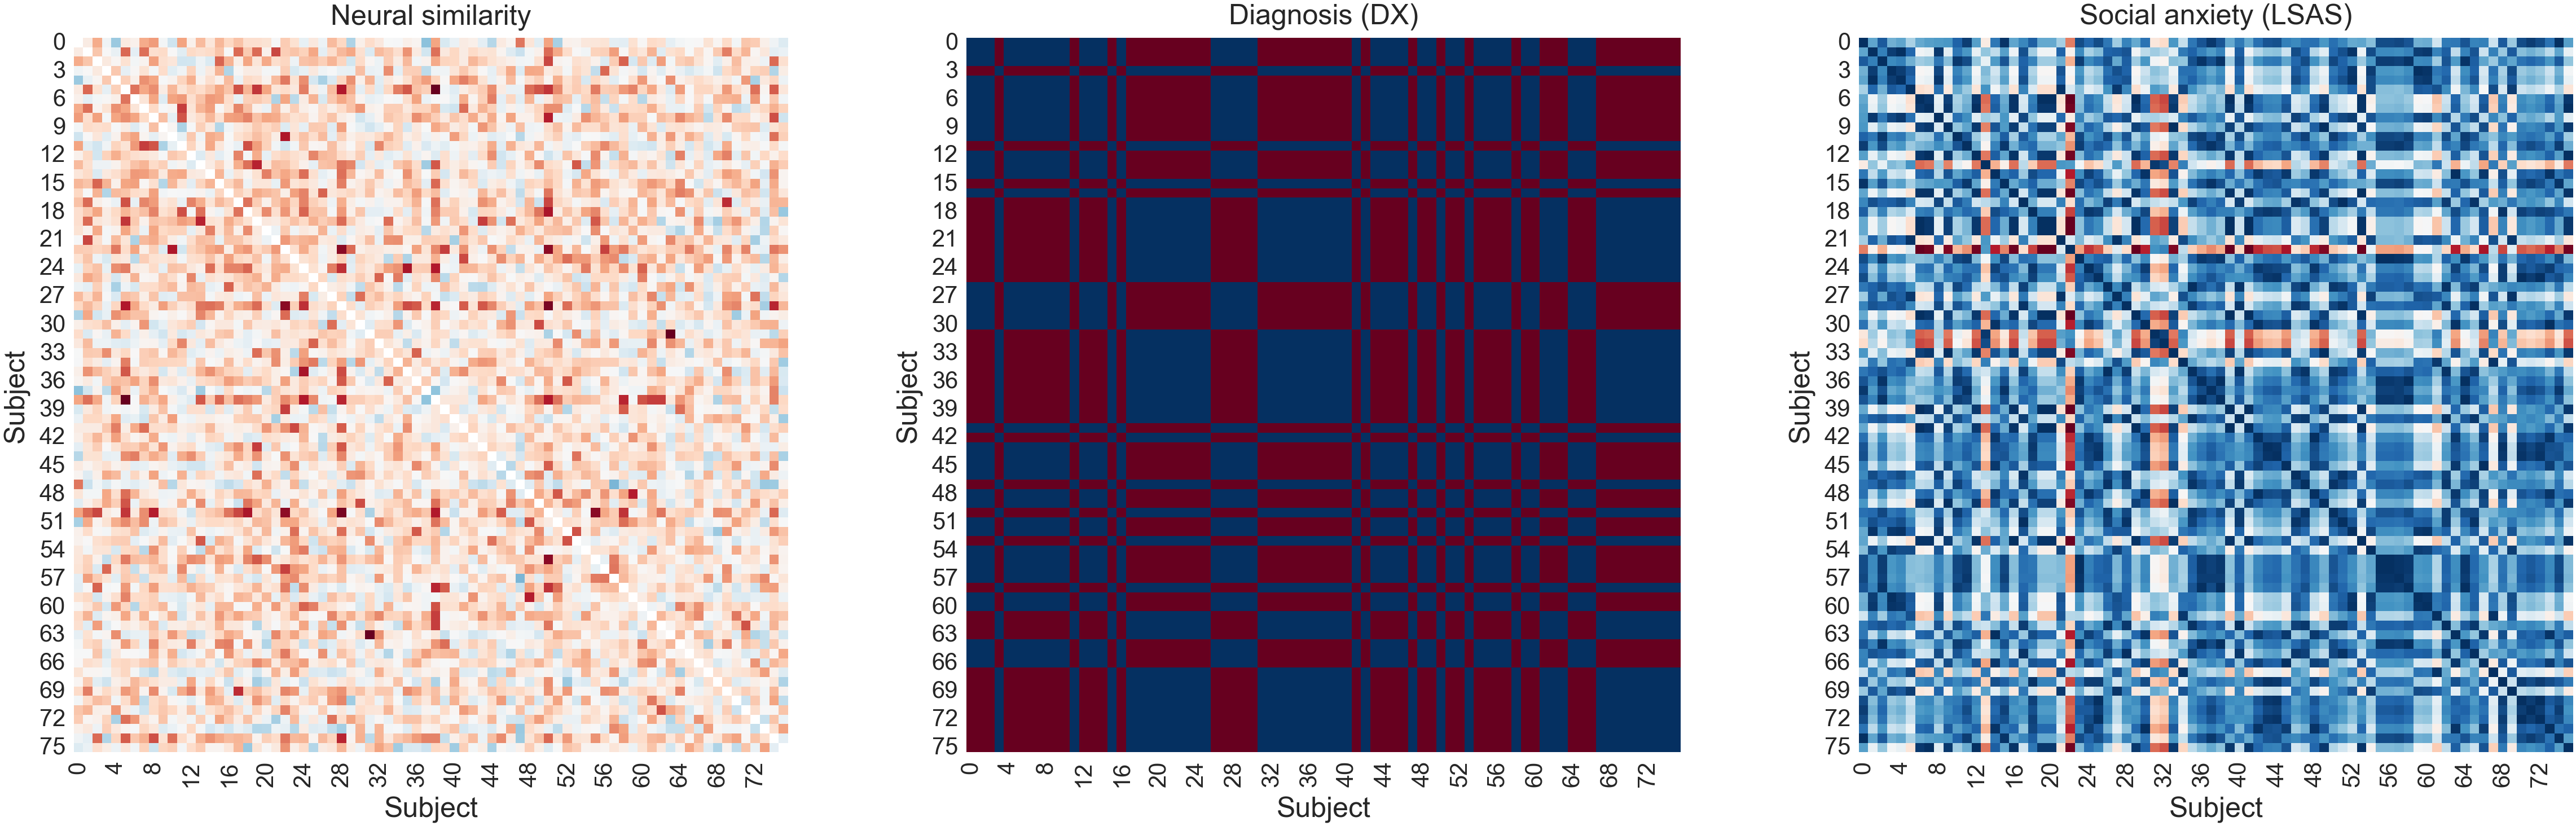

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

ax = axs[0]
M = rsm_roi.values.copy()
np.fill_diagonal(M, np.nan)
v = np.nanmax(np.abs(M))
sns.heatmap(
    M,
    ax=ax,
    cmap="RdBu_r",
    vmin=-v,
    vmax=+v,
    center=0,
    square=True,
    cbar_kws=dict(label="Neural similarity"),
)
ax.set_title("Neural similarity")

ax = axs[1]
sns.heatmap(
    rdm_dx,
    ax=ax,
    cmap="RdBu_r",
    square=True,
    cbar_kws=dict(label="Neural similarity"),
)
ax.set_title("Diagnosis (DX)")

ax = axs[2]
sns.heatmap(
    rdm_sa,
    ax=ax,
    cmap="RdBu_r",
    square=True,
    cbar_kws=dict(label="Neural similarity"),
)
ax.set_title("Social anxiety (LSAS)")

for ax in axs:
    ax.set_xlabel("Subject")
    ax.set_ylabel("Subject")
    ax.collections[0].colorbar.remove()
plt.tight_layout()